# TT-12 — Ridge Regression: Phân bổ ngân sách quảng cáo đa kênh


In [2]:
# 1. Nạp dữ liệu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dummy Data HSS.csv")
print(df.shape)
df.info()
df.describe()


(4572, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   object 
 4   Sales         4566 non-null   float64
dtypes: float64(4), object(1)
memory usage: 178.7+ KB


,TV,Radio,Social Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [3]:
# Kiểm tra dữ liệu thiếu & one-hot encode biến phân loại Influencer
print("Số dòng thiếu dữ liệu theo cột:")
print(df.isna().sum())

df = df.dropna().reset_index(drop=True)  # loại các dòng thiếu (tỉ lệ nhỏ so với 4572 dòng)
df = pd.get_dummies(df, columns=["Influencer"], drop_first=True)
print("Sau xử lý:", df.shape)
df.head()


Số dòng thiếu dữ liệu theo cột:
TV              10
Radio            4
Social Media     6
Influencer       0
Sales            6
dtype: int64
Sau xử lý: (4546, 7)


,TV,Radio,Social Media,Sales,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,16.0,6.566231,2.907983,54.732757,True,False,False
1,13.0,9.237765,2.409567,46.677897,True,False,False
2,41.0,15.886446,2.913410,150.177829,True,False,False
3,83.0,30.020028,6.922304,298.246340,True,False,False
4,15.0,8.437408,1.405998,56.594181,False,True,False


## 2. Ma trận tương quan + VIF — chứng minh đa cộng tuyến

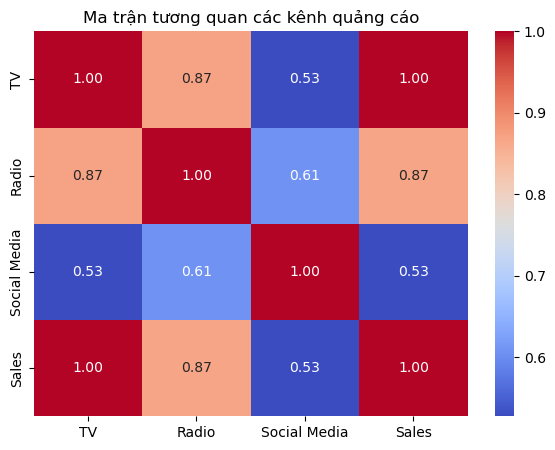

In [4]:
feature_cols = [c for c in df.columns if c != "Sales"]
X = df[feature_cols]
y = df["Sales"]

plt.figure(figsize=(7, 5))
sns.heatmap(df[["TV", "Radio", "Social Media", "Sales"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Ma trận tương quan các kênh quảng cáo")
plt.show()
# TV và Radio thường được bơm ngân sách cùng lúc -> tương quan cao -> nghi ngờ đa cộng tuyến


In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.astype(float)
vif = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)
print(vif)
# VIF > 10 ở TV/Radio -> xác nhận đa cộng tuyến, cần Ridge để ổn định hệ số


            feature        VIF
1             Radio  21.149393
0                TV  19.539399
2      Social Media   5.028400
3   Influencer_Mega   1.528106
4  Influencer_Micro   1.525747
5   Influencer_Nano   1.519812


## 3. Linear Regression (chưa chuẩn hoá regularization) — hệ số làm mốc so sánh

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_pipe = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())])
lr_pipe.fit(X_train, y_train)

he_so_lr = pd.Series(lr_pipe["lr"].coef_, index=X.columns)
print(he_so_lr.sort_values(key=abs, ascending=False))
print("RMSE Linear:", np.sqrt(mean_squared_error(y_test, lr_pipe.predict(X_test))))


TV                  93.321221
Influencer_Nano     -0.039233
Social Media        -0.032047
Influencer_Micro    -0.026033
Radio               -0.024923
Influencer_Mega      0.006212
dtype: float64
RMSE Linear: 2.8849035183403


## 4. Thí nghiệm ổn định: bootstrap 100 lần — Linear vs Ridge

In [7]:
from sklearn.linear_model import Ridge

def bootstrap_coefs(model_fn, X, y, n_iter=100, frac=0.8, seed=42):
    rng = np.random.default_rng(seed)
    coefs = []
    for _ in range(n_iter):
        idx = rng.choice(len(X), size=int(frac * len(X)), replace=False)
        Xs, ys = X.iloc[idx], y.iloc[idx]
        pipe = Pipeline([("scale", StandardScaler()), ("model", model_fn())])
        pipe.fit(Xs, ys)
        coefs.append(pipe["model"].coef_)
    return pd.DataFrame(coefs, columns=X.columns)

coefs_linear = bootstrap_coefs(lambda: LinearRegression(), X_train, y_train)
coefs_ridge = bootstrap_coefs(lambda: Ridge(alpha=10.0), X_train, y_train)


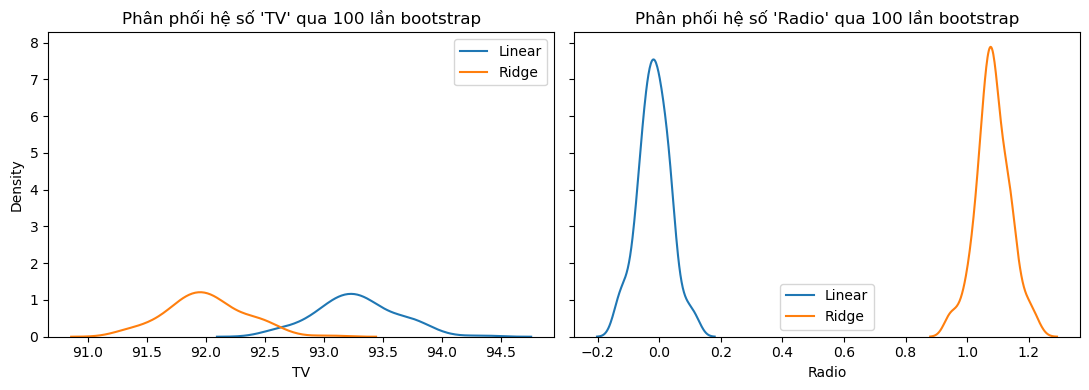

Độ lệch chuẩn hệ số (đo độ dao động):
                  Linear_std  Ridge_std
TV                  0.344733   0.333913
Radio               0.052163   0.054766
Social Media        0.029100   0.028679
Influencer_Mega     0.030402   0.030549
Influencer_Micro    0.030210   0.032189
Influencer_Nano     0.029695   0.031191


In [8]:
# So sánh phân phối hệ số TV & Radio (2 biến tương quan cao nhất) giữa Linear và Ridge
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col in zip(axes, ["TV", "Radio"]):
    sns.kdeplot(coefs_linear[col], label="Linear", ax=ax)
    sns.kdeplot(coefs_ridge[col], label="Ridge", ax=ax)
    ax.set_title(f"Phân phối hệ số '{col}' qua 100 lần bootstrap")
    ax.legend()
plt.tight_layout()
plt.show()
print("Độ lệch chuẩn hệ số (đo độ dao động):")
print(pd.DataFrame({"Linear_std": coefs_linear.std(), "Ridge_std": coefs_ridge.std()}))
# Kỳ vọng: Linear dao động mạnh (std lớn) ở TV/Radio, Ridge ổn định hơn hẳn


## 5. RidgeCV — dò alpha bằng cross-validation (KHÔNG dùng tập test)

In [9]:
from sklearn.linear_model import RidgeCV

ridge_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)),
])
ridge_pipe.fit(X_train, y_train)
alpha_toi_uu = ridge_pipe["ridge"].alpha_
print("Alpha tối ưu (chọn bằng CV trên tập train):", alpha_toi_uu)


Alpha tối ưu (chọn bằng CV trên tập train): 0.06866488450043001


## 6.  Coefficient path — hệ số co dần theo alpha nhưng không chạm 0

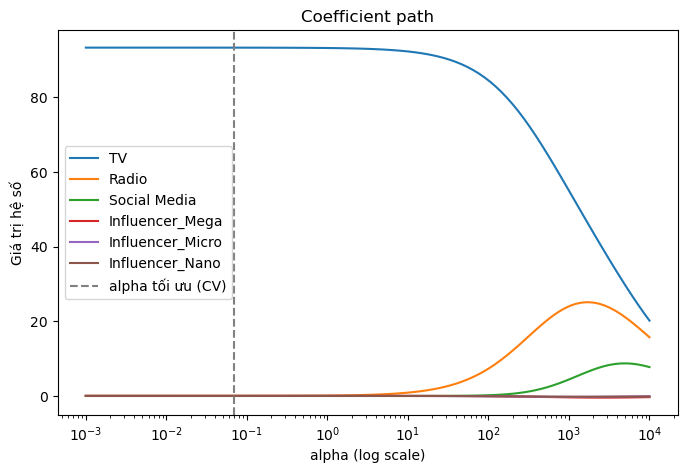

In [10]:
X_train_scaled = StandardScaler().fit_transform(X_train)
alphas = np.logspace(-3, 4, 100)
paths = np.array([Ridge(alpha=a).fit(X_train_scaled, y_train).coef_ for a in alphas])

plt.figure(figsize=(8, 5))
for i, col in enumerate(X.columns):
    plt.plot(alphas, paths[:, i], label=col)
plt.xscale("log")
plt.axvline(alpha_toi_uu, color="gray", linestyle="--", label="alpha tối ưu (CV)")
plt.xlabel("alpha (log scale)"); plt.ylabel("Giá trị hệ số")
plt.title("Coefficient path")
plt.legend()
plt.show()


## 7. RMSE train/test theo alpha — tìm điểm cân bằng bias-variance

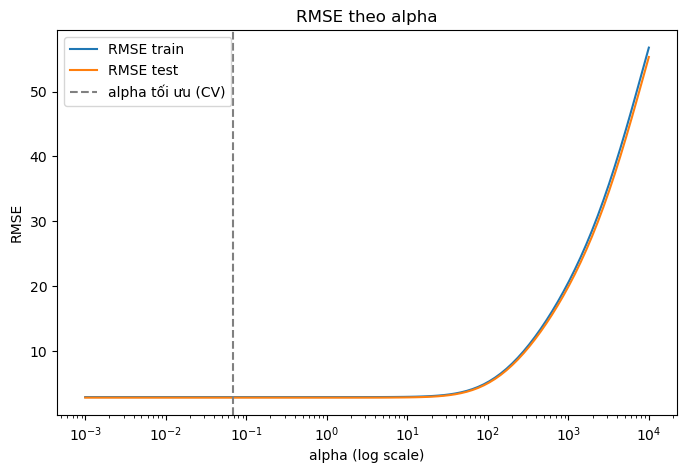

In [11]:
X_test_scaled = StandardScaler().fit(X_train).transform(X_test)
rmse_train, rmse_test = [], []
for a in alphas:
    m = Ridge(alpha=a).fit(X_train_scaled, y_train)
    rmse_train.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train_scaled))))
    rmse_test.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test_scaled))))

plt.figure(figsize=(8, 5))
plt.plot(alphas, rmse_train, label="RMSE train")
plt.plot(alphas, rmse_test, label="RMSE test")
plt.axvline(alpha_toi_uu, color="gray", linestyle="--", label="alpha tối ưu (CV)")
plt.xscale("log")
plt.xlabel("alpha (log scale)"); plt.ylabel("RMSE")
plt.title("RMSE theo alpha")
plt.legend()
plt.show()


## 8. So sánh RMSE: Linear vs Ridge (trên tập test)

In [12]:
rmse_linear = np.sqrt(mean_squared_error(y_test, lr_pipe.predict(X_test)))
rmse_ridge = np.sqrt(mean_squared_error(y_test, ridge_pipe.predict(X_test)))
print(f"Linear Regression RMSE: {rmse_linear:.3f}")
print(f"Ridge (alpha={alpha_toi_uu:.3f}) RMSE: {rmse_ridge:.3f}")


Linear Regression RMSE: 2.885
Ridge (alpha=0.069) RMSE: 2.885


## 9. So sánh với Lasso và ElasticNet

In [13]:
from sklearn.linear_model import LassoCV, ElasticNetCV

lasso_pipe = Pipeline([("scale", StandardScaler()), ("lasso", LassoCV(cv=5, random_state=42))])
lasso_pipe.fit(X_train, y_train)

enet_pipe = Pipeline([("scale", StandardScaler()), ("enet", ElasticNetCV(cv=5, random_state=42))])
enet_pipe.fit(X_train, y_train)

for name, model in [("Ridge", ridge_pipe), ("Lasso", lasso_pipe), ("ElasticNet", enet_pipe)]:
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    print(f"{name:12s} RMSE={rmse:.3f}")


Ridge        RMSE=2.885
Lasso        RMSE=2.883
ElasticNet   RMSE=11.003


## 10. Đề xuất phân bổ ngân sách dựa trên hệ số Ridge

In [14]:
he_so_ridge = pd.Series(ridge_pipe["ridge"].coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(he_so_ridge)

ty_le = (he_so_ridge[["TV", "Radio", "Social Media"]].clip(lower=0))
ty_le = ty_le / ty_le.sum()
print("\nĐề xuất tỉ lệ phân bổ ngân sách 2 tỷ/tháng theo mức ảnh hưởng (hệ số Ridge):")
for kenh, ty in ty_le.items():
    print(f" - {kenh}: {ty:.1%}  (~{ty*2000:.0f} triệu/tháng)")


TV                  93.314025
Influencer_Nano     -0.039284
Social Media        -0.032038
Influencer_Micro    -0.026105
Radio               -0.018678
Influencer_Mega      0.006132
dtype: float64

Đề xuất tỉ lệ phân bổ ngân sách 2 tỷ/tháng theo mức ảnh hưởng (hệ số Ridge):
 - TV: 100.0%  (~2000 triệu/tháng)
 - Radio: 0.0%  (~0 triệu/tháng)
 - Social Media: 0.0%  (~0 triệu/tháng)


## 11. Vì sao Ridge ổn định hơn Linear Regression

Khi hai biến (TV, Radio) tương quan cao, có vô số cặp hệ số (w₁, w₂) cho cùng một
giá trị dự đoán gần đúng — Linear Regression có thể chọn bất kỳ cặp nào trong số đó,
kể cả cặp cực đoan (một biến rất dương, biến kia rất âm), miễn MSE nhỏ nhất trên đúng
tập train đó. Số hạng phạt `λ·Σwᵢ²` của Ridge khiến các cặp hệ số cực đoan bị phạt nặng
hơn nhiều so với cặp hệ số vừa phải chia đều ảnh hưởng — vì vậy Ridge luôn nghiêng về
nghiệm "chia đều", ổn định qua các lần lấy mẫu khác nhau (bootstrap chứng minh điều này).

**Vì sao Ridge không đưa hệ số về đúng 0:** đạo hàm của phạt L2 (`2λw`) tiến về 0 khi
`w` tiến về 0, nên lực "kéo" hệ số về 0 yếu dần và không đủ để đẩy hệ số qua 0 hẳn —
khác với Lasso (phạt L1, đạo hàm là hằng số `λ`, luôn đủ lực đẩy hệ số về đúng 0).

## 12. Hạn chế

- Hệ số hồi quy (kể cả sau Ridge) **không phải quan hệ nhân quả** — cần A/B test hoặc geo-test thật để khẳng định kênh nào thực sự tạo ra doanh thu tăng thêm.
- Dữ liệu hiện tại là cắt ngang theo ngày/tuần, **chưa tính hiệu ứng trễ (adstock)**: quảng cáo TV hôm nay có thể ảnh hưởng doanh thu tuần sau, chưa được mô hình hoá.
- Chưa tính hiệu ứng bão hoà ngân sách (chi gấp đôi không cho doanh thu gấp đôi).